In [1]:
from schnetpack.md.utils import HDF5Loader
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from schnetpack.md.utils import MDUnits

%load_ext autoreload
%autoreload 2

In [2]:
#data = HDF5Loader('md_logs/2022-09-26_uyWZ6jDB/simulation_gpu_resorcinol_dipole_003_start_8-11_compressed.hdf5', load_properties=True, skip_initial=10000)
data = HDF5Loader('md_logs/2023-01-13_Cr2KibUW/simulation_resorcinol_cluster_all_001_compressed.hdf5', load_properties=True, skip_initial=50000)

Shape: (279999, 1)
Shape: [[-18.852814 ]
 [-13.341604 ]
 [ -7.7933764]
 ...
 [-23.422989 ]
 [-22.623148 ]
 [-22.951077 ]]


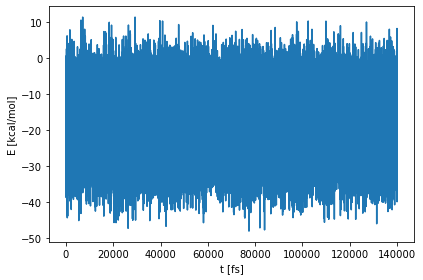

In [3]:
energies = data.get_property('energy')
print('Shape:', energies.shape)
print('Shape:', energies)

# Get the time axis
time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

# Plot the energies
plt.figure()
plt.plot(time_axis, energies)
plt.ylabel('E [kcal/mol]')
plt.xlabel('t [fs]')
plt.tight_layout()
plt.show()

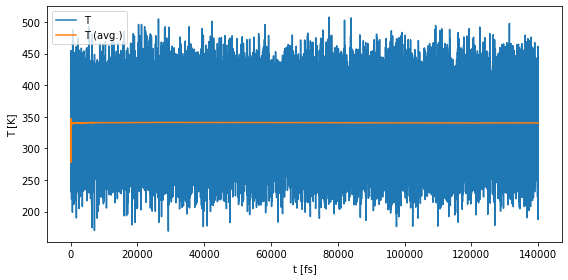

In [4]:
def plot_temperature(data):

    # Read the temperature
    temperature = data.get_temperature()

    # Compute the cumulative mean
    temperature_mean = np.cumsum(temperature) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, temperature, label='T')
    plt.plot(time_axis, temperature_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_temperature(data)

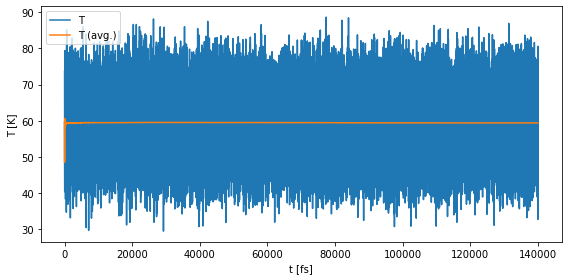

In [5]:
def plot_k_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy()

    # Compute the cumulative mean
    k_energy_mean = np.cumsum(k_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, k_energy, label='T')
    plt.plot(time_axis, k_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_k_energy(data)

std potential 7.755253
std kinetic 1.8439712574416303
energy_unit 0.010364269574711572
kcal 2.5196637345688e+24
kJ 6.022140857000001e+23
ha 2625.4996387552483


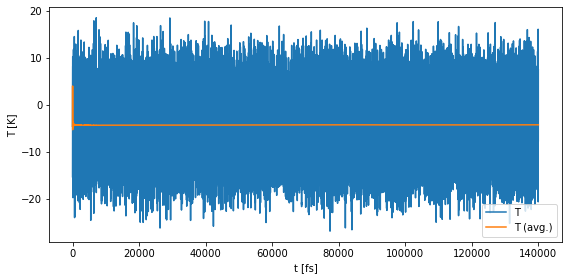

In [6]:
def plot_total_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy() *  MDUnits.conversions['kj']/MDUnits.conversions['kcal']
    p_energy = data.get_property('energy').squeeze()
    print('std potential', np.std(p_energy))
    print('std kinetic', np.std(k_energy))
    print('energy_unit', MDUnits.energy_unit)
    print('kcal', MDUnits.conversions['kcal'])
    print('kJ', MDUnits.conversions['kj'])
    print('ha', MDUnits.conversions['ha'])
    total_energy = k_energy + p_energy

    # Compute the cumulative mean
    total_energy_mean = np.cumsum(total_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, total_energy, label='T')
    plt.plot(time_axis, total_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_total_energy(data)

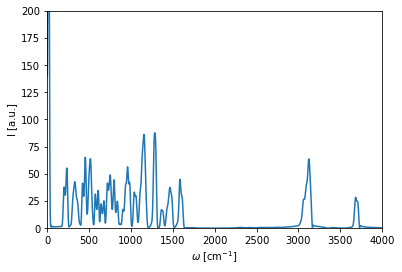

In [7]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



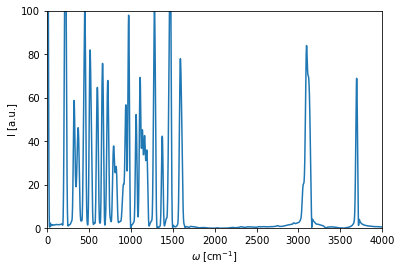

In [8]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=1)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



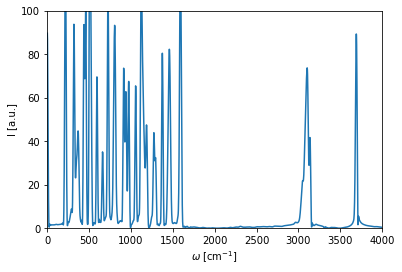

In [9]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=2)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')


#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_vib_spectrum.svg')
plt.show()

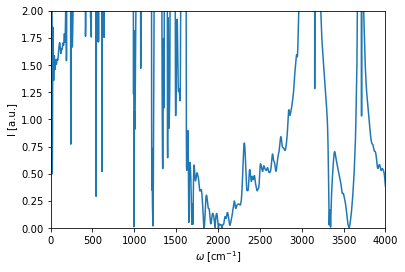

In [10]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=3)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,2)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')


#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_vib_spectrum.svg')
plt.show()

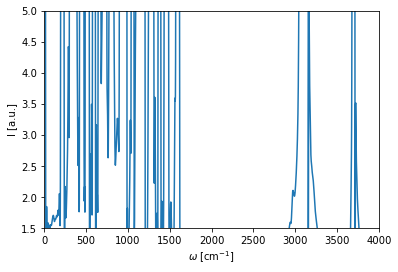

In [11]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=3)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(1.5, 5)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')


#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_vib_spectrum.svg')
plt.show()

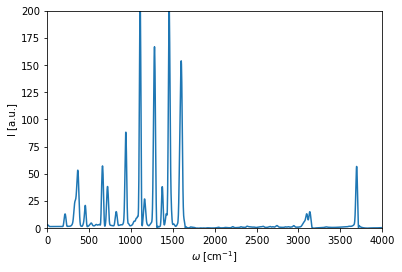

In [12]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=1)
freqencies, intensities_1 = spectrum.get_spectrum()
#k_len = 20
#x_kern = np.linspace(-1, 1, k_len)
#w_1 = 1
#k_amp_1 = 1
#kernel_1 = k_amp_1*(np.exp(-(x_kern/w_1)**2)/np.sum(np.exp(-(x_kern/w_1)**2)))
#intensities_1 = np.convolve(intensities_1, kernel_1)[int(k_len/2):][:-(int(k_len/2)-1)]

# Plot the spectrum
plt.figure()
#plt.plot(freqencies, intensities_1)
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_resorcinol_IR_spectrum_1.svg')
plt.show()


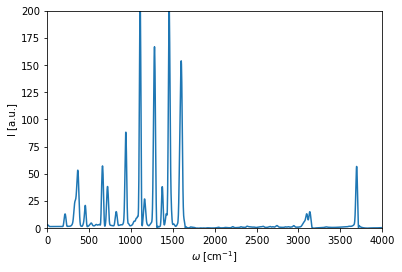

In [13]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=1)
freqencies, intensities_1 = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities_1)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_resorcinol_IR_spectrum_1.svg')
plt.show()

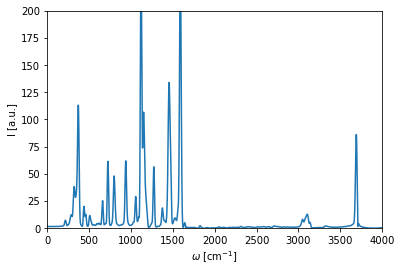

In [14]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=2)
freqencies, intensities_2 = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities_2)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_resorcinol_IR_spectrum_2.svg')
plt.show()


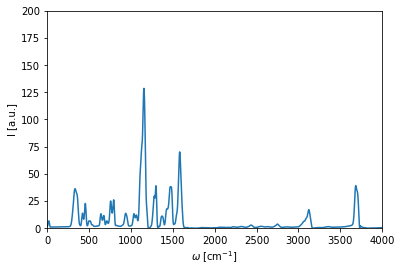

In [57]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities_0 = spectrum.get_spectrum()

k_len = 20
x_kern = np.linspace(-1, 1, k_len)
w_1 = 0.1
k_amp_1 = 0.7 
kernel_1 = k_amp_1*(np.exp(-(x_kern/w_1)**2)/np.sum(np.exp(-(x_kern/w_1)**2)))
intensities_0[:1000] = np.convolve(intensities_0[:1040], kernel_1)[int(k_len/2): int(k_len/2)+ 1000]
#print(np.convolve(intensities_0, kernel_1)[int(k_len/2): int(k_len/2)+ 1000].shape)

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities_0)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_resorcinol_IR_spectrum_0.svg')
plt.show()

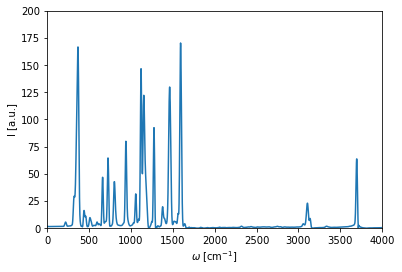

In [16]:
import jcamp

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=3)
freqencies, intensities_3 = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities_3)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_resorcinol_IR_spectrum_3.svg')
plt.show()


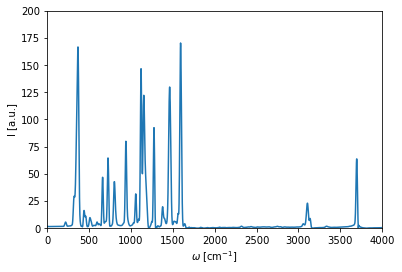

In [17]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=3)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_resorcinol_IR_spectrum_3.svg')
plt.show()


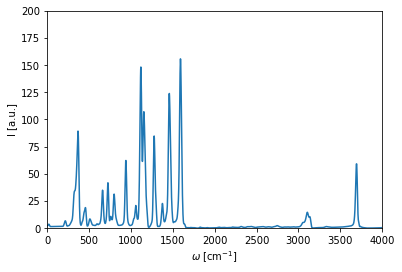

In [18]:
from schnetpack.md.utils.spectra import IRSpectrum

#spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

#spectrum.compute_spectrum(molecule_idx=1)
#freqencies, intensities = spectrum.get_spectrum()

intensities = np.mean(np.stack([intensities_0, intensities_1, intensities_2, intensities_3], axis=1), axis=1)
# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,200)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_resorcinol_IR_spectrum_combined.svg')
plt.show()

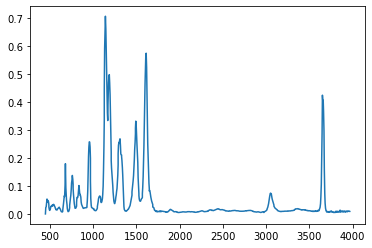

In [19]:
import jcamp

jcamp_data = jcamp.JCAMP_reader('datasets/resorcinol_IR.jdx')
#print(jcamp_data)
x = np.round(jcamp_data['x'])
y = jcamp_data['y']
#y = - np.log(y)
plt.plot(x, y)
plt.show()

In [20]:
freqs = np.round(freqencies)
f_count = 0
f_match = []
x_count = 0
x_match = []

while f_count < len(freqs) and x_count < len(x):
    if freqs[f_count] == x[x_count]:
        f_match.append(f_count)
        x_match.append(x_count)
        f_count += 1
        x_count += 1
    elif freqs[f_count] < x[x_count]:
        f_count += 1
    else:
        x_count += 1

print(len(f_match))
print(len(x_match))
print(freqs[f_match])
print(x[x_match])

394
394
[ 450.  454.  468.  472.  499.  503.  517.  521.  548.  552.  566.  570.
  574.  588.  592.  597.  601.  619.  623.  637.  641.  654.  668.  672.
  686.  690.  694.  708.  717.  721.  739.  743.  757.  761.  766.  770.
  774.  788.  792.  806.  810.  814.  823.  837.  841.  859.  863.  877.
  886.  890.  894.  908.  912.  926.  930.  934.  939.  943.  957.  961.
  979.  983. 1006. 1010. 1014. 1028. 1032. 1046. 1059. 1063. 1077. 1081.
 1099. 1103. 1108. 1112. 1126. 1130. 1134. 1148. 1152. 1179. 1183. 1197.
 1201. 1228. 1232. 1246. 1250. 1254. 1268. 1272. 1277. 1281. 1299. 1303.
 1317. 1321. 1334. 1348. 1352. 1366. 1370. 1374. 1388. 1397. 1401. 1419.
 1423. 1437. 1441. 1450. 1454. 1468. 1472. 1486. 1490. 1494. 1503. 1517.
 1521. 1539. 1543. 1557. 1566. 1570. 1574. 1588. 1592. 1606. 1610. 1614.
 1619. 1623. 1637. 1641. 1659. 1663. 1686. 1690. 1694. 1708. 1712. 1726.
 1739. 1743. 1757. 1761. 1779. 1783. 1788. 1792. 1806. 1810. 1814. 1828.
 1832. 1859. 1863. 1877. 1881. 1908. 1912. 

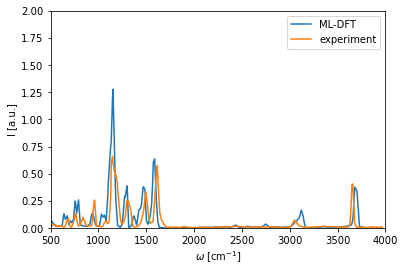

In [59]:
plt.figure()
#plt.plot(freqs[f_match]*0.95 + 100, intensities[f_match]/100)
plt.plot(freqs[f_match], intensities_0[f_match]/100, label='ML-DFT')
plt.plot(x[x_match], y[x_match], label='experiment')
plt.xlim(500, 4000)
plt.ylim(0,2)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.legend()
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_resorcinol_IR_spectrum_comp_new_1.svg')
plt.savefig('/home/mihail/Documents/workspace/equiv_dens/figures/ml_resorcinol_IR_spectrum_comp_new_0.1.pdf')
plt.show()

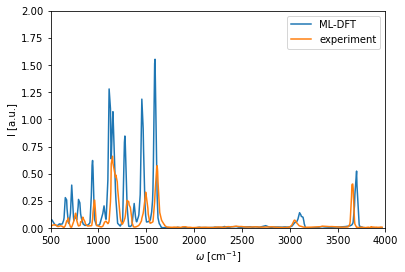

In [22]:
plt.figure()
#plt.plot(freqs[f_match]*0.95 + 100, intensities[f_match]/100)
plt.plot(freqs[f_match], intensities[f_match]/100, label='ML-DFT')
plt.plot(x[x_match], y[x_match], label='experiment')
plt.xlim(500, 4000)
plt.ylim(0,2)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.legend()
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/nat_manuscript/figures/ml_resorcinol_IR_spectrum_comp_new_comb.svg')
plt.show()

In [28]:
from schnetpack.md.utils.spectra import fft_autocorrelation
dpm = data.get_property('dipole_moment')
print(dpm.shape)
autocorr = np.zeros((3, dpm.shape[0] - 1))
for i in range(dpm.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(dpm[:, i], dpm.shape[0] - 2)

print(autocorr.shape)

(166600, 3)
i 0
i 1
i 2
(3, 166599)


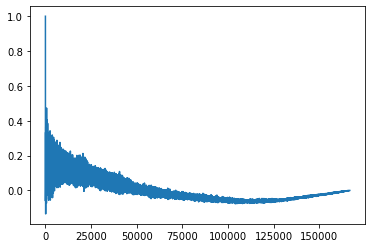

In [29]:
import matplotlib.pyplot as plt

plt.plot(np.mean(autocorr, axis=0))

#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/autocorrelation.svg')
plt.show()

[[-65.74487   99.777695  29.791533]
 [-61.202045 108.73556   36.735653]
 [-33.183334  34.991264  42.539417]
 ...
 [ 21.709322 105.44681  -43.178795]
 [ -7.67374  228.10172  -16.712189]
 [ 10.20944  159.86919  -31.305311]]
i 0
i 1
i 2
(3, 166598)


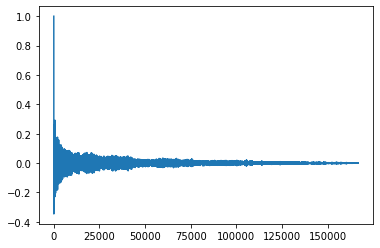

In [30]:
h = 0.5 / 1000

diff = np.diff(dpm, axis=0)
diff = diff/h
print(diff)

autocorr = np.zeros((3, diff.shape[0] - 1))
for i in range(diff.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(diff[:, i], diff.shape[0] - 2)
    
print(autocorr.shape)
plt.plot(np.mean(autocorr, axis=0))

#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/diff_autocorrelation.svg')
plt.show()